<a href="https://colab.research.google.com/github/HieuStudyingCS/Learning-AI-Journey/blob/main/Matrix_Calculus_Gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import numpy as np
from numpy import linalg
import matplotlib.pyplot as plt
from IPython.display import Image, display, HTML

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Vector Calculus

Linear function

$$
\begin{aligned}f: \mathcal{R}^D &\to \mathcal{R} \\  \mathbf{x} &\mapsto f(\mathbf{x})\end{aligned}
$$

Ví dụ như dot product $f(\mathbf{x}) = \mathbf{x}^T\mathbf{x}$, được biểu diễn như sau

$$
\begin{aligned}f: \mathcal{R}^2 &\to \mathcal{R} \\ \mathbf{x} &\mapsto x_1^2 + x_2^2 \end{aligned}
$$

In this chapter, we will discuss how to compute gradients of functions

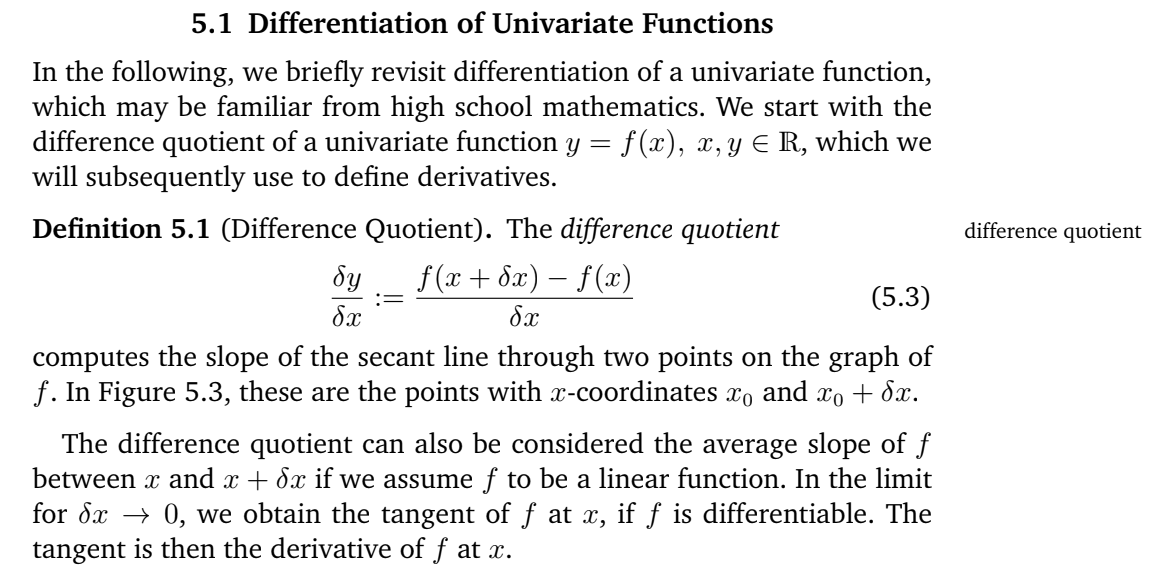

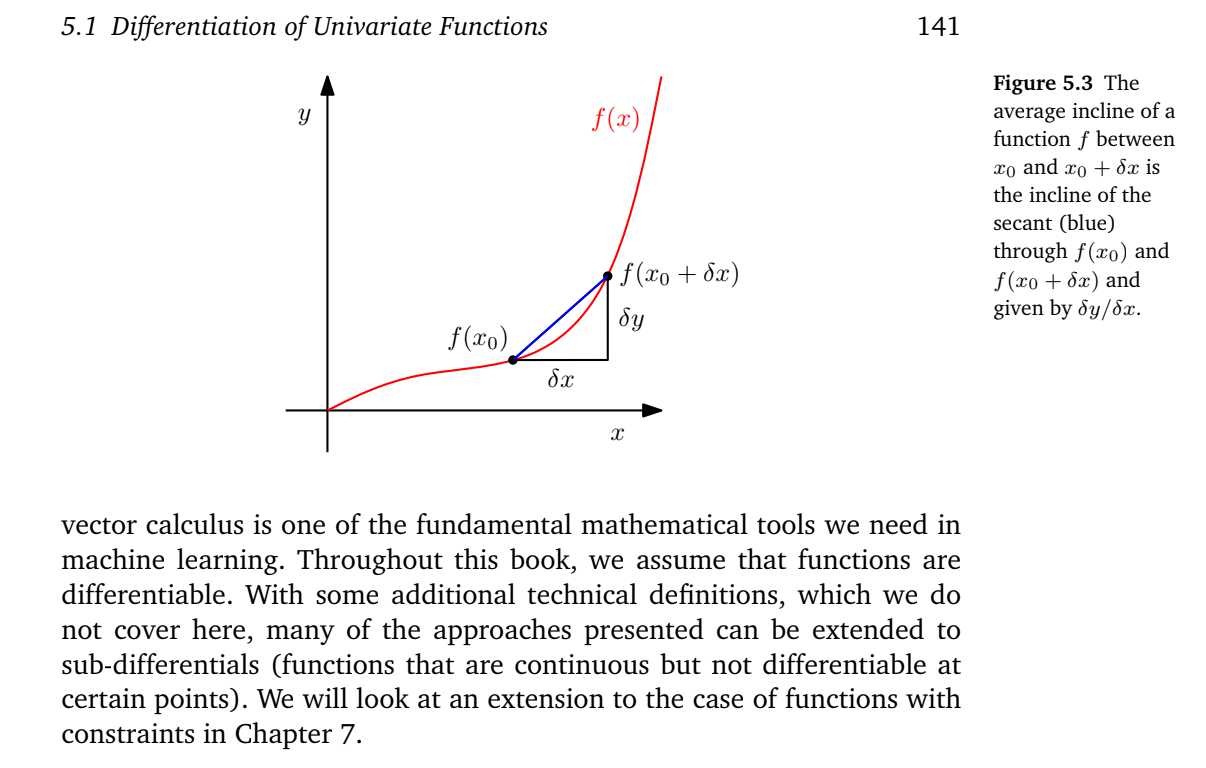

In [40]:
file_path_pic_1 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/1.png'
file_path_pic_2 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/2.png'
display(Image(filename=file_path_pic_2, width=600))
display(Image(filename=file_path_pic_1, width=600))

Trong bức ảnh trên thì tác giả thể hiện khái niệm của đạo hàm, tức là sự thay đổi của hàm số tại một thời điểm

Nhìn vào **figure 5.3** thì ta thấy được hệ số góc của đường thẳng màu xanh dương như sau:

$$
a = \tan(\alpha) = \frac{\delta y}{\delta x} = \frac{f(x_o + \delta x) - f(x_0)}{(x_0 + \delta x) - x_0} = \frac{f(x_o + \delta x) - f(x_0)}{\delta x}
$$

Khi $\delta x \to 0$, then $B(x_0 + \delta x, f(x_0 + \delta x)) \to A(x_0, f(x_0))$.

Nói cách khác thì lúc này đường thẳng màu xanh dương (là cát tuyến của $f(x)$) trở thành đường tiếp tuyến tại $A$ của $f(x)$. Và đường thẳng này mang theo thông tin của độ dốc của hàm số $f(x)$ tại $A$ → Khái niệm này người ta gọi là đạo hàm (derivative).

Công thức tổng quát như sau

$$
\frac{df}{dx} = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}
$$

Trong đó, $h = \delta x > 0$

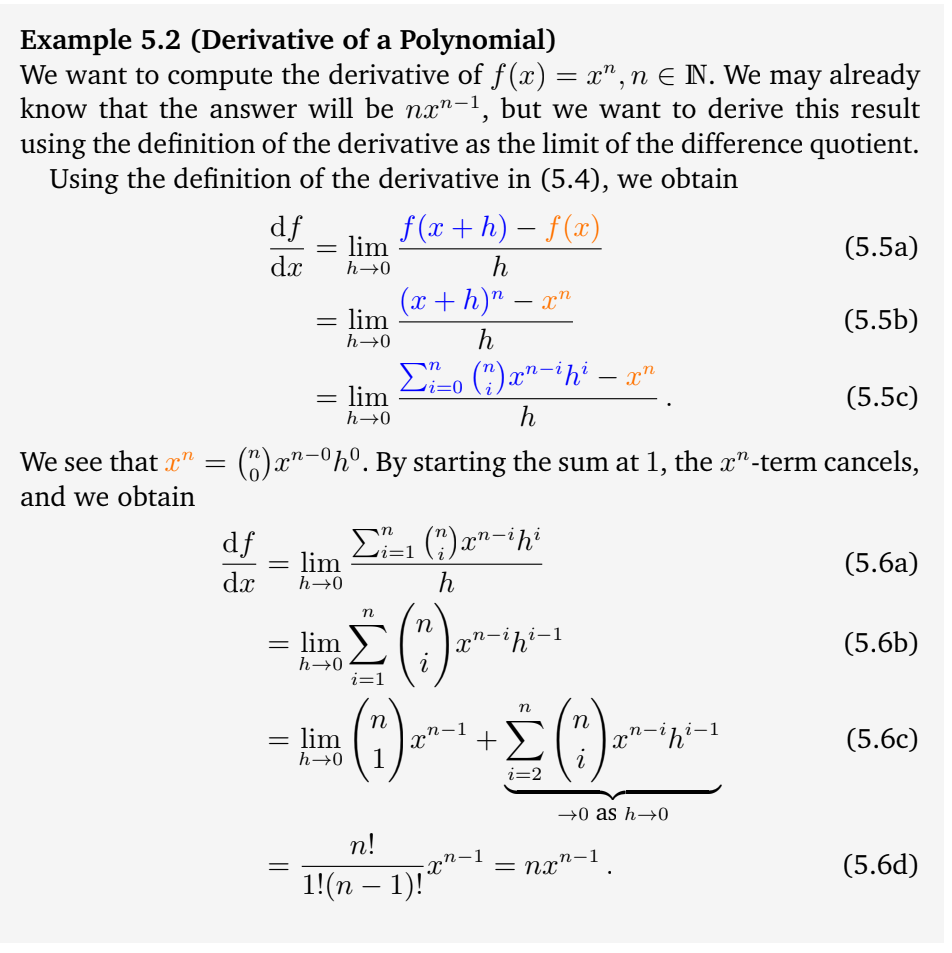

In [41]:
file_path_pic_3 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/3.png'
display(Image(filename=file_path_pic_3, width=600))

Đây là chứng minh lại công thức đạo hàm của hàm đa thức $f’(x) = (x^n)’ = nx^{n-1}$.

# Taylor Series

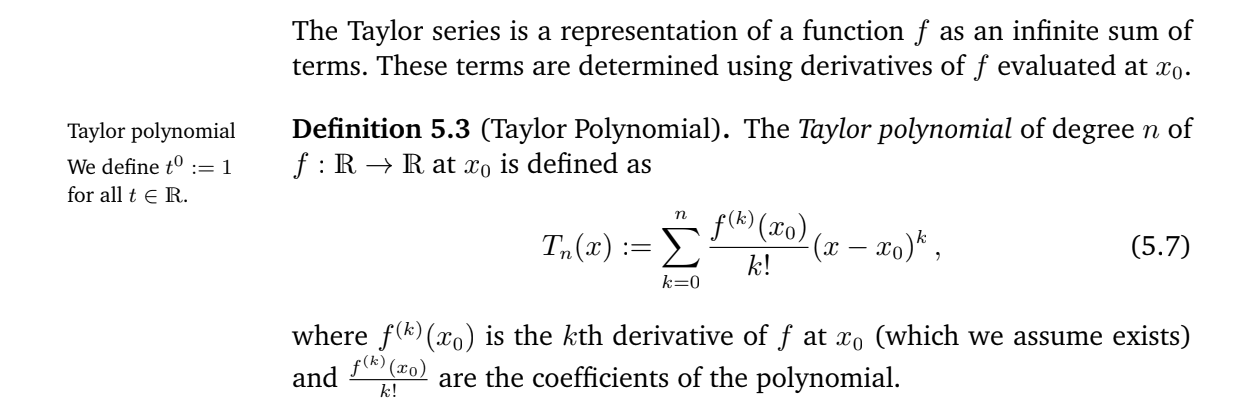

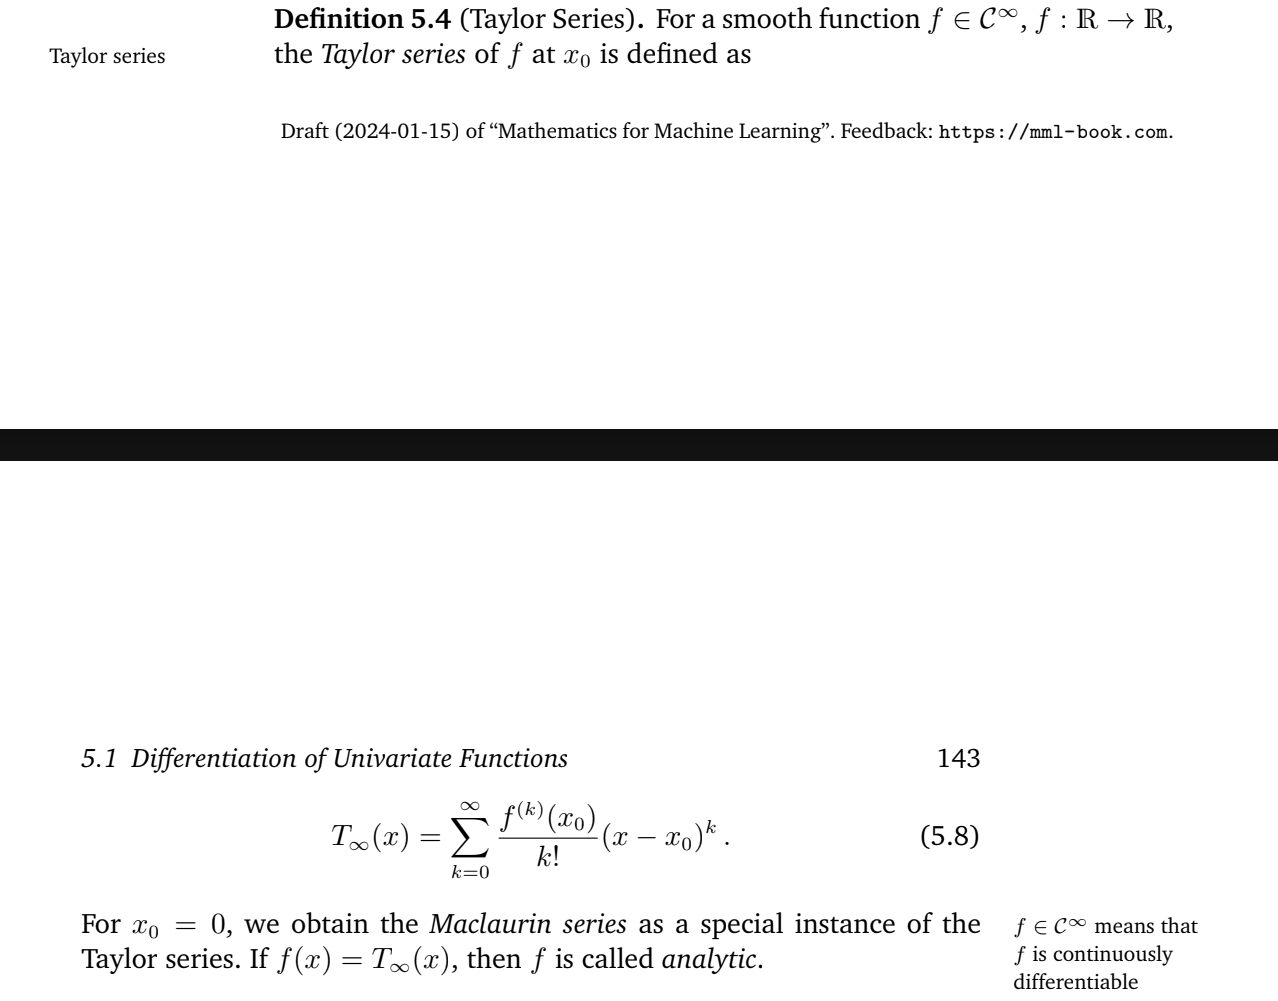

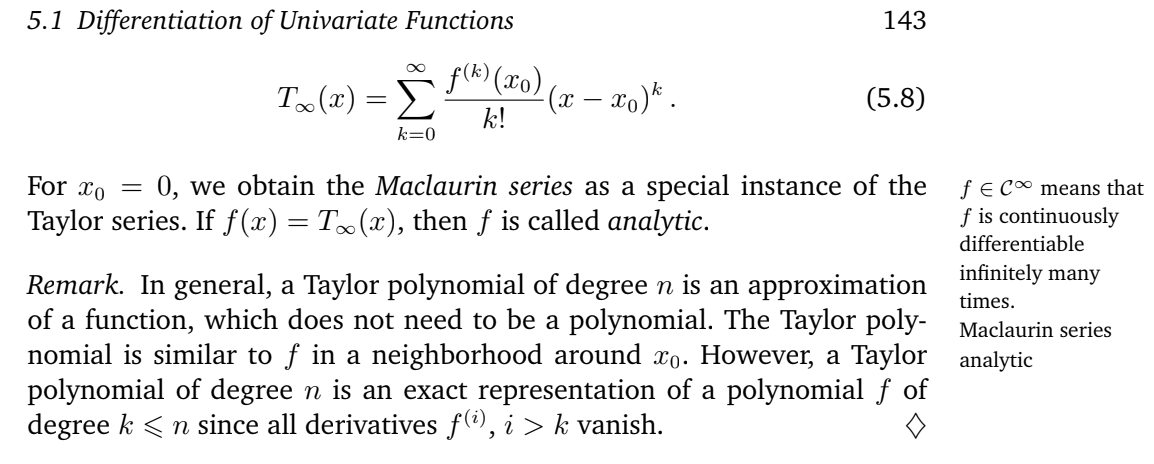

In [42]:
file_path_pic_4 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/4.png'
file_path_pic_5 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/5.png'
file_path_pic_6 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/6.png'
display(Image(filename=file_path_pic_4, width=600))
display(Image(filename=file_path_pic_5, width=600))
display(Image(filename=file_path_pic_6, width=600))

Đoạn cuối:

- Đa thức Taylor bậc $n$ được sử dụng để xấp xỉ một hàm số (không nhất thiết phải là đa thức) trong vùng lân cận của $x_0$.
- Nếu bản thân hàm $f$ đã là một đa thức có bậc $k \leqslant n$, thì đa thức Taylor bậc $n$ sẽ biểu diễn chính xác hoàn toàn hàm $f$ đó. Lý do là vì tất cả các đạo hàm bậc cao hơn $k$ (ký hiệu là $f^{(i)}$ với $i > k$) đều sẽ bằng 0.

Ví dụ sau đây sẽ thể hiện nếu $f$ là một hàm đa thức bậc $k \leq n$ thì đa thức Taylor bậc $n$ sẽ biểu diễn chính xác hoàn toàn hàm $f$:

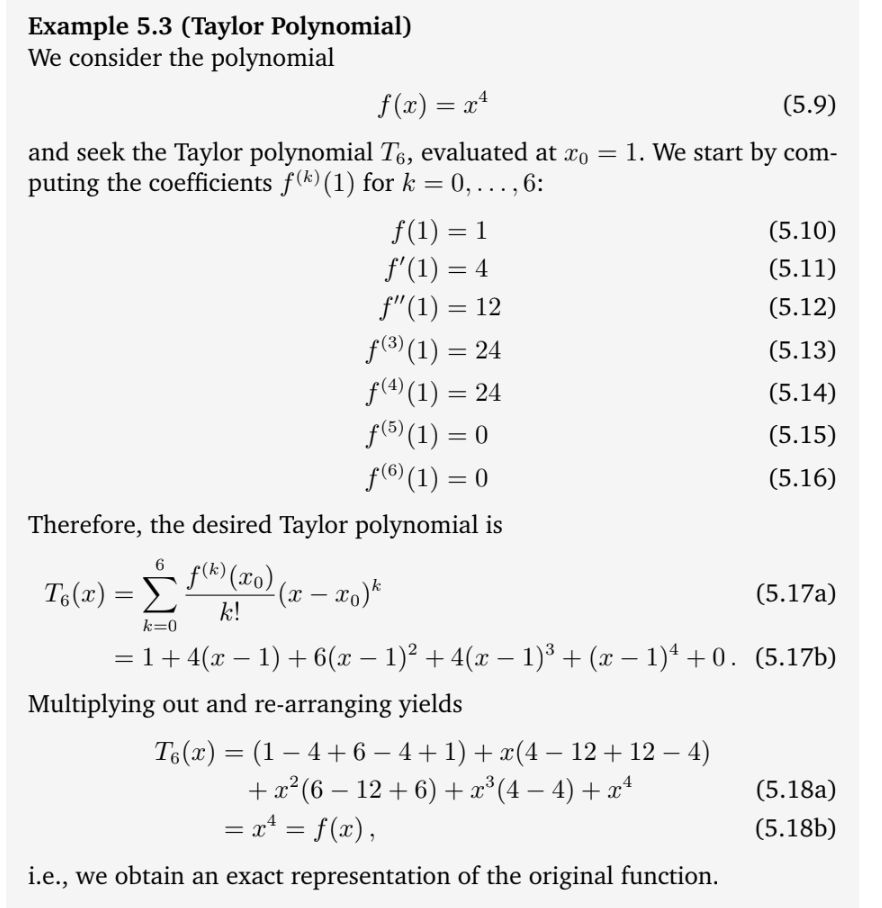

In [43]:
file_path_pic_7 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/7.png'
display(Image(filename=file_path_pic_7, width=600))

Chú ý kí hiệu: $f\in \mathcal{C}^\infty$ có nghĩa là hàm $f$ khả vi liên tục vô hạn lần (smooth)

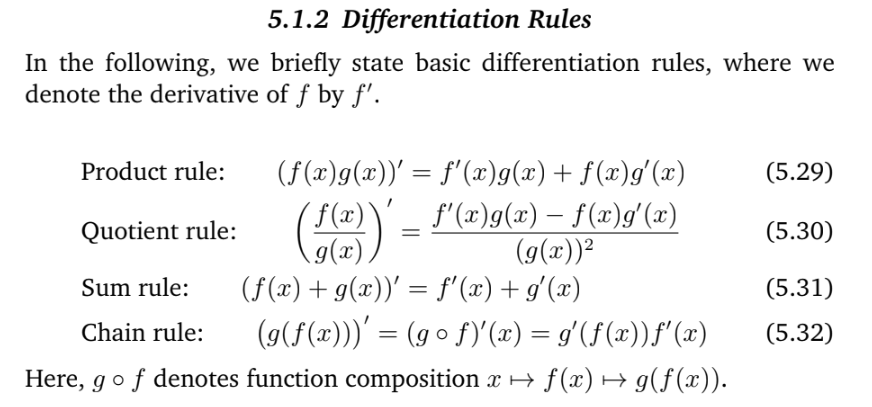

In [44]:
file_path_pic_8 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/8.png'
display(Image(filename=file_path_pic_8, width=600))

# Gradient

## Introduction

Trong phần trên thì mình đã tìm hiểu về Linear Functions, và đạo hàm cho hàm một biến. Nếu đạo hàm của hàm nhiều biến thì ta gọi phép đạo hàm này là Gradient.

- Được áp dụng cho hàm nhiều biến $f(x, y, z,\dots)$ hoặc $f(\mathbf{x})$ với $\mathbf{x}$ là một vector chứa nhiều biến.
- Gradient là tập hợp tất cả các đạo hàm riêng (partial derivatives) của hàm số đó theo từng biến. Và vector được tạo thành từ phép lấy Gradient sẽ chỉ theo hướng của hàm số tăng nhanh nhất từ một điểm cụ thể trong không gian đa chiều, và độ lớn của vector gradient này chính là tốc độ tăng đó.
- Như đã nói ở trên, kết quả của Gradient là một vector có cùng số chiều với không gian đầu vào.
- Ký hiệu: $\nabla f(\mathbf{x})$.
- **Ví dụ:** Nếu $f(x, y) = x^2 + y^3$, thì gradient là một véc-tơ chứa hai đạo hàm riêng:

$$
\nabla f(x, y) = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix} = \begin{bmatrix} 2x \\ 3y^2 \end{bmatrix}
$$

## Gradient của hàm trả về một số vô hướng (hàm vô hướng)

Hàm vô hướng được định nghĩa như sau:

$$
\begin{aligned}f: \mathcal{R}^n &\to \mathcal{R} \\ \mathbf{x} &\mapsto f(\mathbf{x})\end{aligned}
$$

Gradient bậc nhất của hàm này, ký hiệu là $\nabla_{\mathbf{x}} f(\mathbf{x})$ như sau:

$$
\nabla_{\mathbf{x}} f(\mathbf{x}) = \begin{bmatrix} \frac{\partial f(\mathbf{x})}{\partial x_1} \\ \frac{\partial f(\mathbf{x})}{x_2} \\ \dots \\ \frac{\partial f(\mathbf{x})}{x_n}\end{bmatrix} \in \mathcal{R}^n
$$

Trong đó $\frac{\partial f(\mathbf{x})}{x_i}$ là đạo hàm riêng của hàm số theo thành phần thứ $i$ của vector $\mathbf{x}$ được tính như sau

$$
\frac{\partial f}{\partial x_i} = \lim_{h \to 0}\frac{f(x_1 + h, x_2, \dots, x_n) - f(\mathbf{x})}{h}
$$

Ở đây cần lưu ý một chút: Trong sách [1] sử dụng quy ước như sau:

$$
\nabla_{\mathbf{x}} f(\mathbf{x}) = \begin{bmatrix} \frac{\partial f(\mathbf{x})}{\partial x_1} & \frac{\partial f(\mathbf{x})}{x_2} & \dots & \frac{\partial f(\mathbf{x})}{x_n}\end{bmatrix} \in \mathcal{R}^{1\times n}
$$

Trong đó, $n$ là số lượng biến trong vector $\mathbf{x}$ ban đầu. Vector gradient lúc này được trình bày dưới dạng hàng thay vì cột như sách [2] (được dùng theo quy ước của Machine Learning), và ta gọi vector hàng này là gradient của $f$ hay Jacobian.

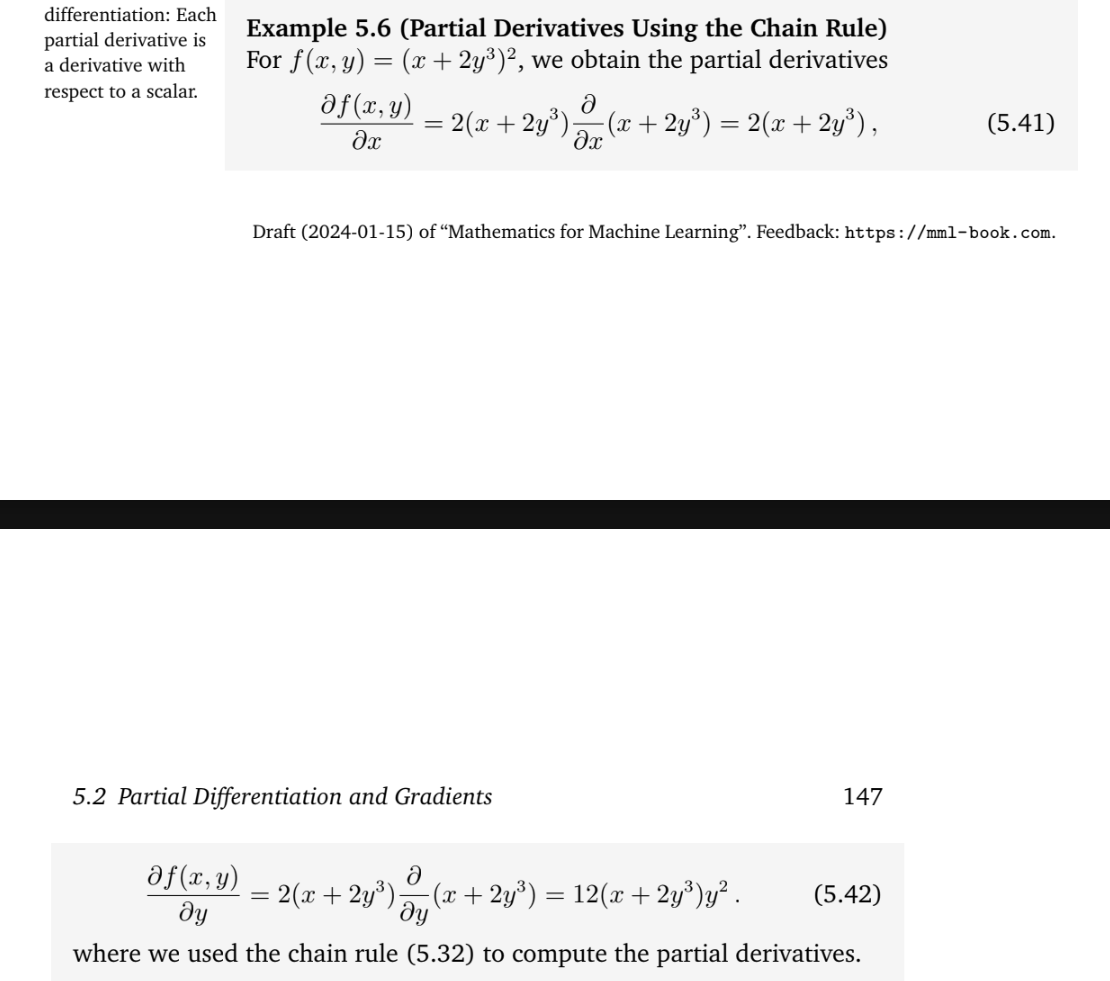

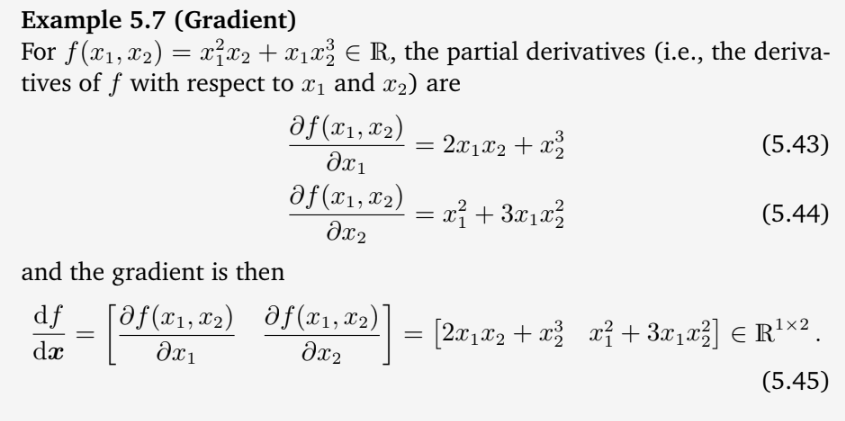

In [45]:
file_path_pic_9 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/9.png'
file_path_pic_10 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/10.png'
display(Image(filename=file_path_pic_9, width=600))
display(Image(filename=file_path_pic_10, width=600))

## Basic rules of partial differentiation

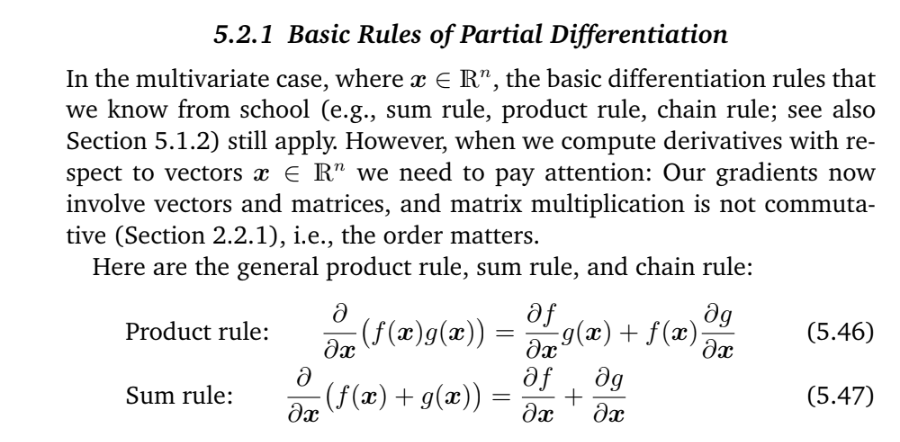

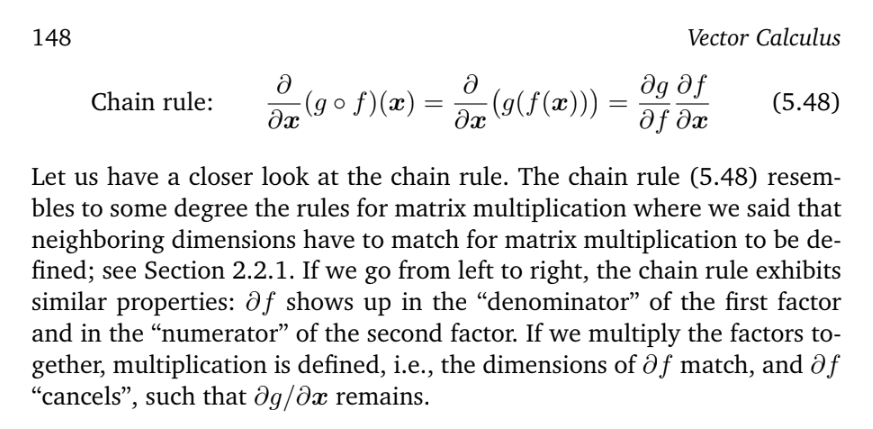

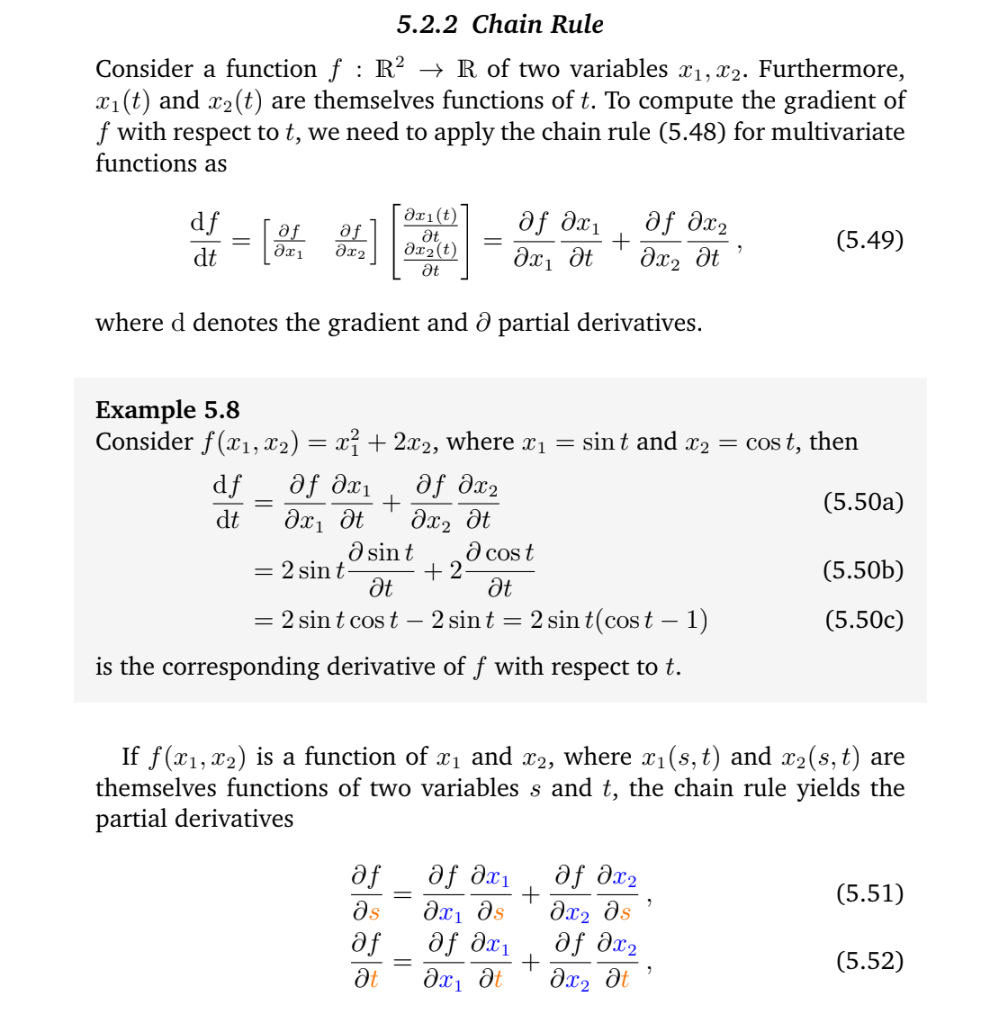

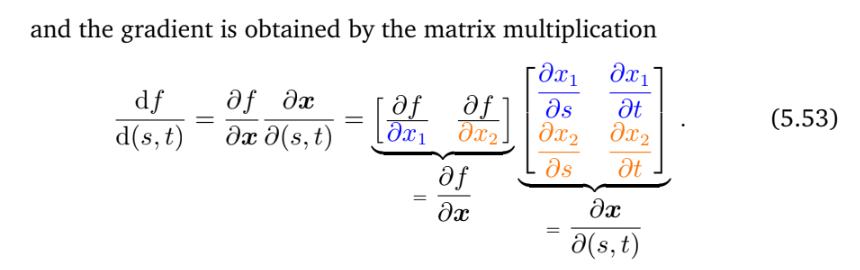

In [46]:
file_path_pic_11 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/11.png'
file_path_pic_12 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/12.png'
file_path_pic_13 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/13.png'
file_path_pic_14 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/14.png'
display(Image(filename=file_path_pic_11, width=600))
display(Image(filename=file_path_pic_12, width=600))
display(Image(filename=file_path_pic_13, width=600))
display(Image(filename=file_path_pic_14, width=600))

Quy tắc tích, áp dụng cho hàm nhận vào một ma trận:

$$
\nabla(f(X)^Tg(X)) = (\nabla f(X))g(X) + (\nabla g(X))f(X)
$$

Gradient bậc 2 của hàm số trên còn được gọi là Hessian và được định nghĩa như sau:

$$
\nabla^2 f(\mathbf{x}) \triangleq  \begin{bmatrix} \frac{\partial^2 f(\mathbf{x})}{\partial x_1^2} & \frac{\partial^2 f(\mathbf{x})}{\partial x_1 \partial x_2} & \cdots & \frac{\partial^2 f(\mathbf{x})}{\partial x_1 \partial x_n} \\ \frac{\partial^2 f(\mathbf{x})}{\partial x_2 \partial x_1} & \frac{\partial^2 f(\mathbf{x})}{\partial x_2^2} & \cdots & \frac{\partial^2 f(\mathbf{x})}{\partial x_2 \partial x_n} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{\partial^2 f(\mathbf{x})}{\partial x_n \partial x_1} & \frac{\partial^2 f(\mathbf{x})}{\partial x_n \partial x_2} & \cdots & \frac{\partial^2 f(\mathbf{x})}{\partial x_n^2} \end{bmatrix} \in \mathbb{S}^n.
$$

Gradient của một hàm số $f(X): \mathcal{R}^{n\times m} \to \mathcal{R}$ theo ma trận $X$ được định nghĩa là

$$
\nabla f(\mathbf{X}) =  \begin{bmatrix} \frac{\partial f(\mathbf{X})}{\partial x_{11}} & \frac{\partial f(\mathbf{X})}{\partial x_{12}} & \cdots & \frac{\partial f(\mathbf{X})}{\partial x_{1m}} \\ \frac{\partial f(\mathbf{X})}{\partial x_{21}} & \frac{\partial f(\mathbf{X})}{\partial x_{22}} & \cdots & \frac{\partial f(\mathbf{X})}{\partial x_{2m}} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{\partial f(\mathbf{X})}{\partial x_{n1}} & \frac{\partial f(\mathbf{X})}{\partial x_{n2}} & \cdots & \frac{\partial f(\mathbf{X})}{\partial x_{nm}} \end{bmatrix} \in \mathbb{R}^{n \times m}
$$

Gradient của hàm số $f: \mathcal{R}^{m\times n} \to \mathcal{R}$ là một ma trận trong $\mathcal{R}^{m \times n}$

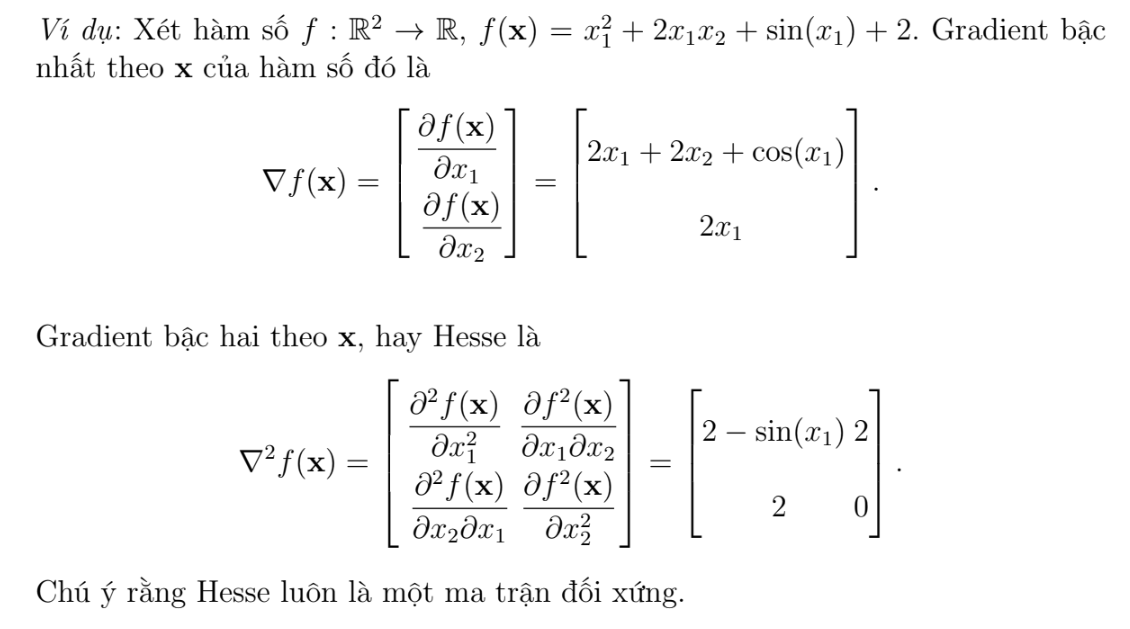

In [47]:
file_path_pic_15 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/15.png'
display(Image(filename=file_path_pic_15, width=600))

## Gradient của hàm trả về vector

Những hàm số mà đầu ra là một vector được gọi là hàm trả về vector (vector-valued function)

Xét một hàm trả về vector với đầu vào là một số thực như sau:

$$
\begin{aligned}v(x): \mathcal{R} &\to \mathcal{R}^n\end{aligned}
$$

$$
v(x) = \begin{bmatrix}v_1(x) \\ v_2(x) \\ \dots \\ v_n(x)\end{bmatrix}
$$

Gradient của hàm số này theo $x$ là một vector hàng như sau:

$$
\nabla v(x) = \begin{bmatrix} \frac{\partial v_1(x)}{\partial x} & \frac{\partial v_2(x)}{\partial x} & \frac{\partial v_3(x)}{\partial x} &\dots  & \frac{\partial v_n(x)}{\partial x}\end{bmatrix}
$$

Và gradient bậc 2 của hàm số này sẽ như sau:

$$
\nabla^2v(x) = \begin{bmatrix} \frac{\partial^2 v_1(x)}{\partial x^2} & \frac{\partial^2 v_2(x)}{\partial x^2} & \frac{\partial^2 v_3(x)}{\partial x^2} &\dots  & \frac{\partial^2 v_n(x)}{\partial x^2}\end{bmatrix}
$$

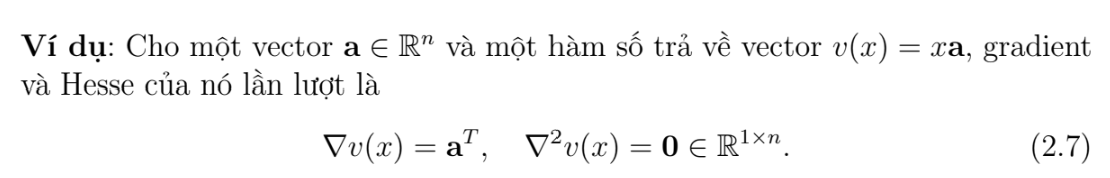

In [48]:
file_path_pic_16 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/16.png'
display(Image(filename=file_path_pic_16, width=600))

Giải:

Ta có:

$$
a = \begin{bmatrix}a_1 \\ a_2 \\ \dots \\ a_n\end{bmatrix}
$$

Áp dụng công thức tính gradient ta có:

$$
\nabla f(x) = \begin{bmatrix}\frac{\partial (xa_1)}{\partial x} & \frac{\partial (xa_2)}{\partial x} & \dots & \frac{\partial (xa_n)}{\partial x}\end{bmatrix} = \begin{bmatrix}a_1 & a_2 & \dots & a_n\end{bmatrix} = \mathbf{a}^T
$$

Dễ thấy vì hàm $f(x) = x\mathbf{a}$ là hàm bậc 1 theo $x$ nên nếu lấy gradient bậc 2, tức là đạo hàm từng phần theo $x^2$ thì kết quả là một vector hàng $\mathbf{0}$.

Xét hàm trả về một vector với đầu vào là một vector như sau:

$$
\begin{aligned}h(\mathbf{x}): \mathcal{R}^k &\to \mathcal{R}^n\end{aligned}
$$

hay

$$
h(\mathbf{x}) = \begin{bmatrix}h_1(\mathbf{x}) \\ h_2(\mathbf{x}) \\ \dots \\ h_n(\mathbf{x}) \end{bmatrix}
$$

Với các hàm $h_i(\mathbf{x}): \mathcal{R}^k \to \mathcal{R}$ là các hàm vô hướng

Gradient của hàm $h(\mathbf{x})$ được tính như sau:

$$
\nabla h(\mathbf{x}) \triangleq  \begin{bmatrix} \frac{\partial h_1(\mathbf{x})}{\partial x_1} & \frac{\partial h_2(\mathbf{x})}{\partial x_1} & \cdots & \frac{\partial h_n(\mathbf{x})}{\partial x_1} \\ \frac{\partial h_1(\mathbf{x})}{\partial x_2} & \frac{\partial h_2(\mathbf{x})}{\partial x_2} & \cdots & \frac{\partial h_n(\mathbf{x})}{\partial x_2} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{\partial h_1(\mathbf{x})}{\partial x_k} & \frac{\partial h_2(\mathbf{x})}{\partial x_k} & \cdots & \frac{\partial h_n(\mathbf{x})}{\partial x_k} \end{bmatrix} = [\nabla h_1(\mathbf{x}) \dots \nabla h_n(\mathbf{x})] \in \mathbb{R}^{k \times n} \tag{1}
$$

Quy tắc tính có thể hiểu như sau:

- Vì các hàm $h_i(\mathbf{x})$ là các hàm vô hướng nên gradient của hàm này trả về một vector cột có đạo hàm riêng theo từng thành phần, xếp các vector cột này lại thành một ma trận ta được ma trận gradient của hàm $h(\mathbf{x})$.

Gradient của hàm số $g: \mathcal{R}^m \to \mathcal{R}^n$ là một ma trận thuộc $\mathcal{R}^{m\times n}$

Phần này cũng cần chú ý về ký hiệu toán học như sau:

Trong sách [1] sẽ trình bày theo chuẩn toán học như sau:

Cho hàm số trả về vector với đầu vào là một vector $\mathbf{f}: \mathcal{R}^n \to \mathcal{R}^m$ với vector $\mathbf{x} = \begin{bmatrix}x_1 & x_2 & \dots & x_n\end{bmatrix}^T \in \mathcal{R}^n$

$$
f(\mathbf{x}) = \begin{bmatrix}f_1(\mathbf{x}) \\ \dots \\ f_m(\mathbf{x})\end{bmatrix} \in \mathcal{R}^m
$$

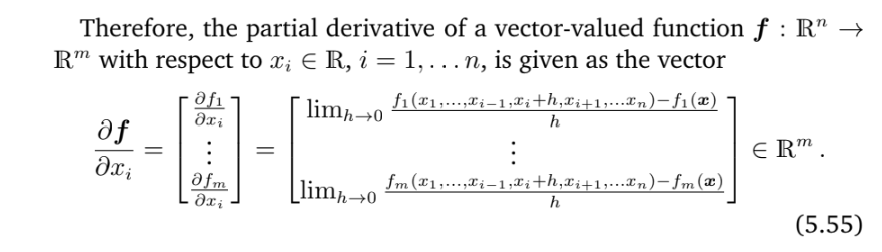

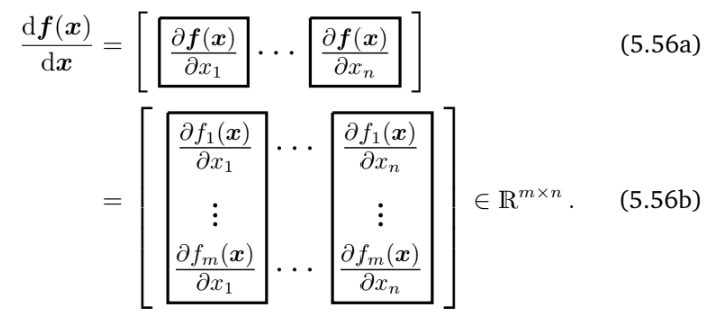

In [49]:
file_path_pic_17 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/17.png'
file_path_pic_18 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/18.png'
display(Image(filename = file_path_pic_17, width=600))
display(Image(filename=file_path_pic_18, width=600))

- Tới đây thì ta thấy có chút sự khác biệt là ma trận (5.56b) trong sách [1] là chuyển vị của ma trận tương tự trong sách [2]. Sự khác biệt này dẫn tới hệ quả trong ma trận Jacobian được trình bày bên dưới

## Jacobian

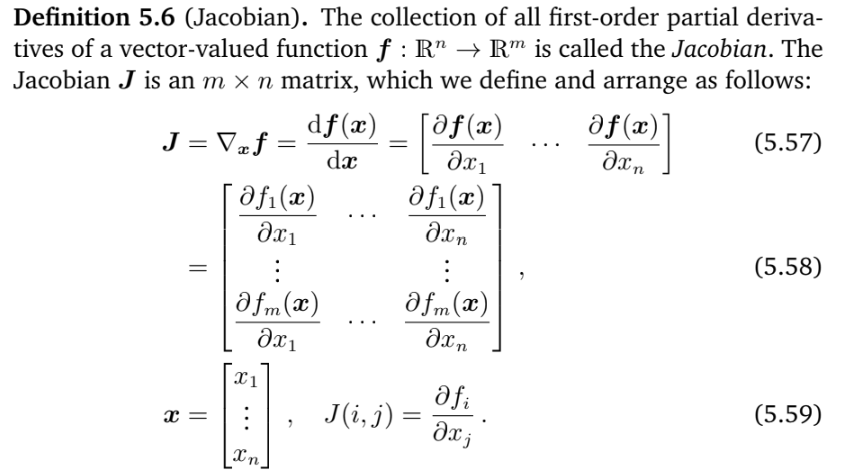

In [50]:
file_path_pic_19 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/19.png'
display(Image(filename=file_path_pic_19, width=600))

Dạng ma trận được trình bày phía trên (trong sách [1]) có định dạng là “numerator layout” (chuẩn toán học), nhưng vẫn còn một dạng trình bày nữa được sử dụng nhiều trong máy học và học sâu là chuyển vị của ma trận numerator layout, được gọi là denominator layout (là ma trận (1) phía trên).

## Kết quả của một số gradient thường gặp

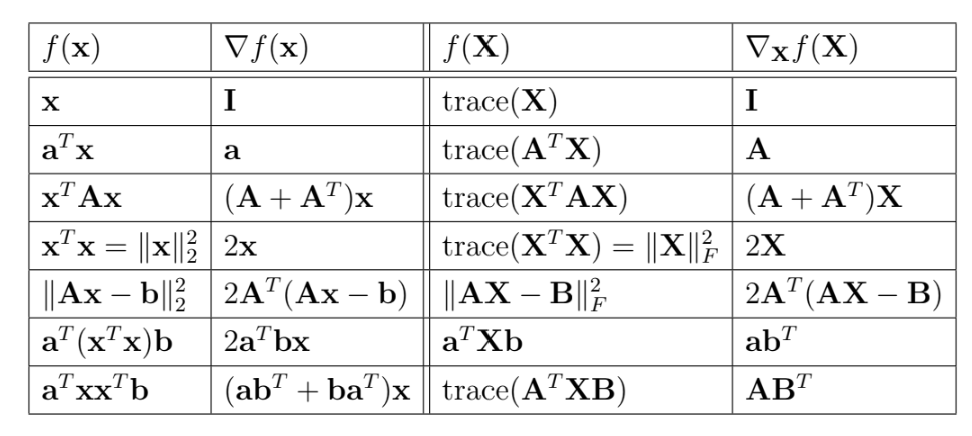

In [51]:
file_path_pic_20 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/20.png'
display(Image(filename=file_path_pic_20, width=600))

## Xấp xỉ Gradient - Kiểm tra gradient
Trong phần này thì mình sẽ học về phương pháp tính xấp xỉ Gradient

Trong thực tế việc tính Gradient của hàm nhiều biến thông thường khá phức tạp và dễ có sai xót. Trong thực nghiệm thì chúng ta có phương pháp để kiểm tra liệu Gradient có được tính đúng hay không.

## Xấp xỉ đạo hàm của hàm một biến
Ta có định nghĩa của đạo hàm của hàm một biến như sau:
$$
f'(x) = \lim_{\epsilon \to 0} \frac{f(x+\epsilon) - f(x)}{\epsilon}
$$

Khi cài đặt bằng công thức này, ta có thể chọn $\epsilon$ rất nhỏ khoảng $10^{-6}$, thì ta có phép xấp xỉ sau:
$$
f'(x) \approx \lim_{\epsilon \to 0} \frac{f(x+\epsilon) - f(x)}{\epsilon}
$$

Tuy nhiên, trên thực tế chúng ta lại sử dụng công thức xấp xỉ đạo hàm hai phía sau đây hơn:
$$
f'(x) \approx \lim_{\epsilon \to 0} \frac{f(x+\epsilon) - f(x - \epsilon)}{2\epsilon}
$$

Cách tính trên được gọi là numerical gradient và chúng ta có giải thích tính hiệu quả của numerical gradient cho việc xấp xỉ đạo hàm sau đây:
### Chứng minh hình học



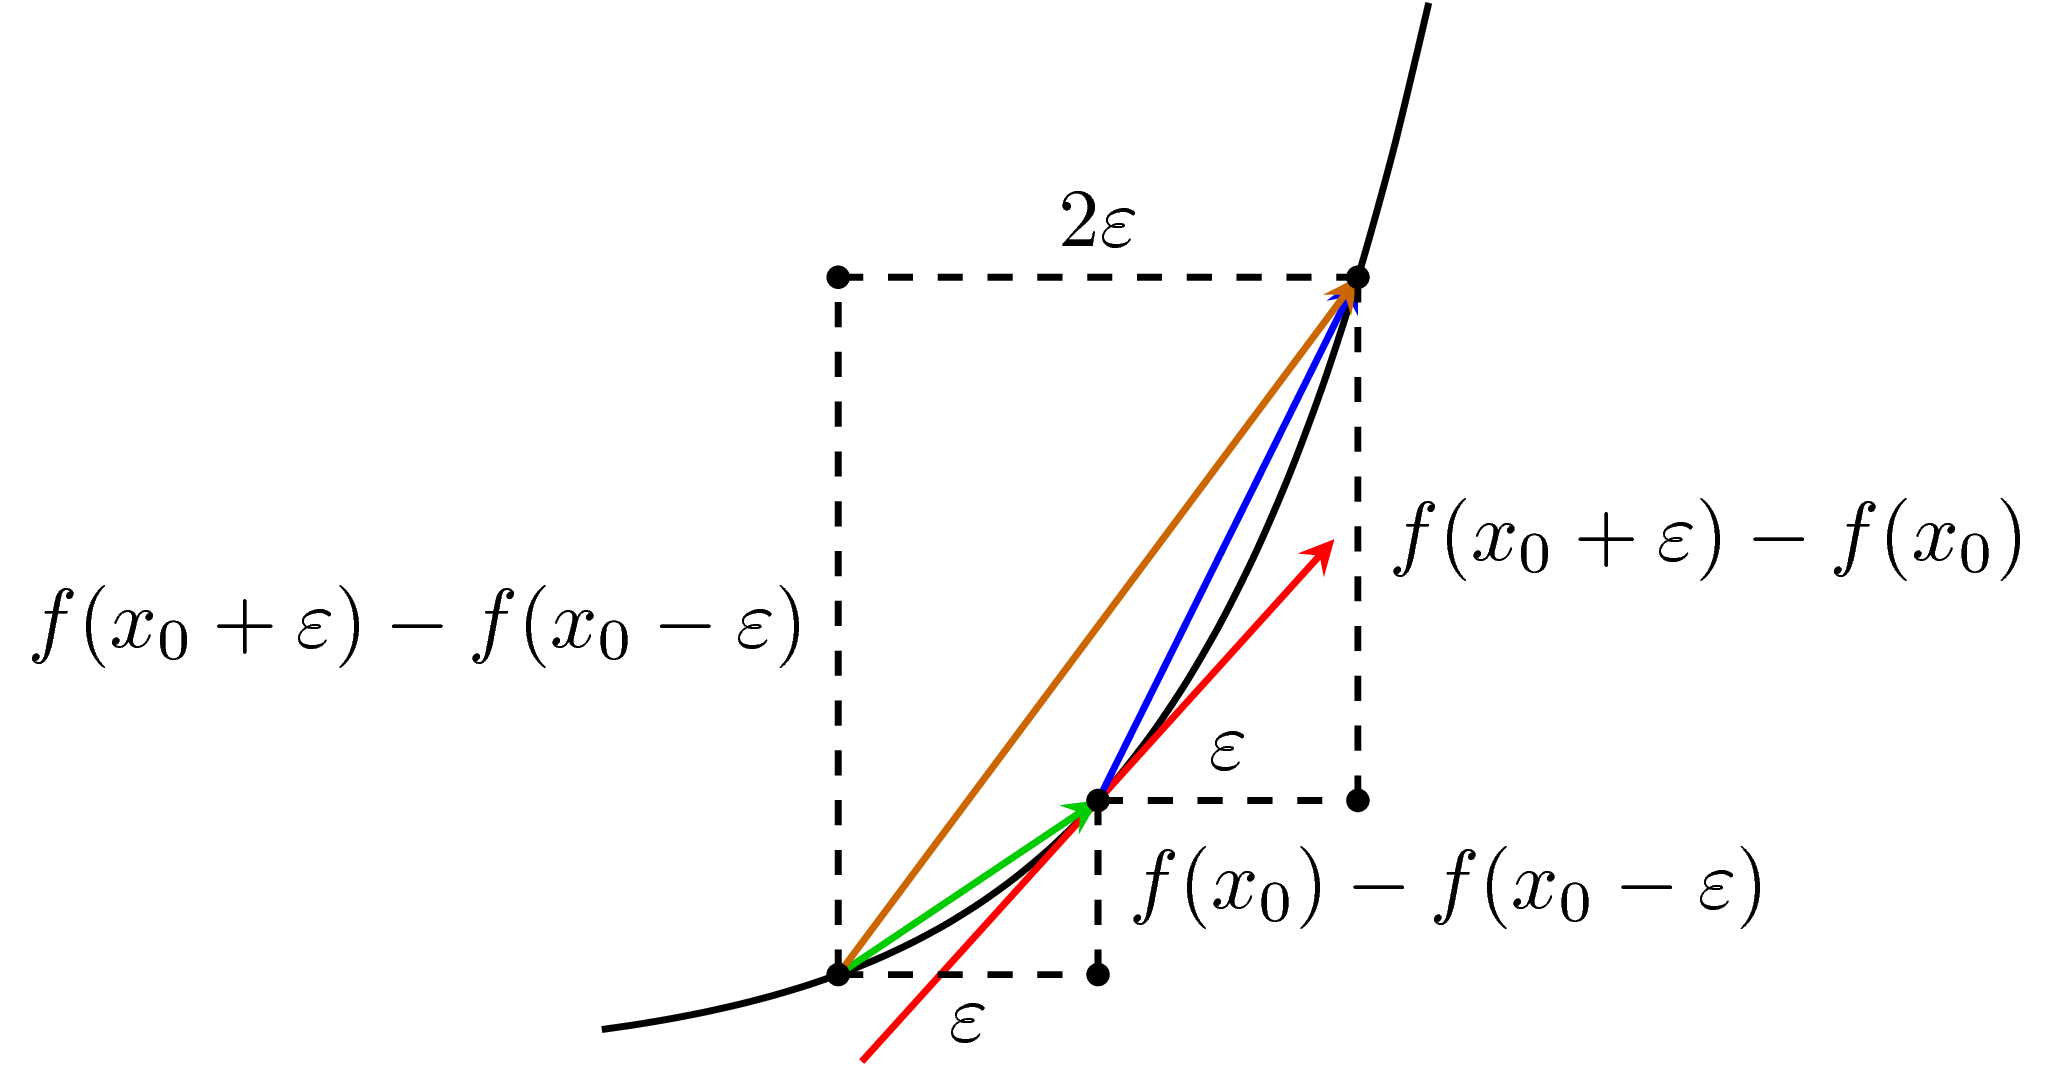

In [52]:
file_path_pic_21 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/21.png'
display(Image(filename=file_path_pic_21, width=600))

Trong hình, vector màu đỏ là đạo hàm *chính xác* của hàm số tại điểm có hoành độ bằng $x_0$. Vector màu xanh lam thể hiện cách xấp xỉ đạo hàm phía phải. Vector màu xanh lục thể hiện cách xấp xỉ đạo hàm phía trái. Vector màu nâu thể hiện cách xấp xỉ đạo hàm hai phía. Trong ba vector xấp xỉ đó, vector xấp xỉ hai phía màu nâu là gần với vector đỏ nhất nếu xét theo hướng.

Sự khác biệt giữa các cách xấp xỉ còn lớn hơn nữa nếu tại điểm $x$, hàm số bị *bẻ cong* mạnh hơn. Khi đó, xấp xỉ trái và phải sẽ khác nhau rất nhiều. Xấp xỉ hai bên sẽ *ổn định* hơn.

### Chứng minh Giải tích
Ý tưởng là sử dụng chuỗi Taylor  
Với $\epsilon$ rất nhỏ, ta có xấp xỉ sau đây:

$$
f(x + \varepsilon) \approx f(x) + f'(x)\varepsilon + \frac{f''(x)}{2}\varepsilon^{2} + \dots
$$

Và:

$$
f(x- \varepsilon) \approx f(x) - f'(x)\varepsilon + \frac{f''(x)}{2}\varepsilon^{2} - \dots
$$

Từ đây, ta có:

$$
\frac{f(x + \varepsilon) - f(x)}{\varepsilon} \approx f'(x) + \frac{f''(x)}{2}\varepsilon + \dots = f'(x) + O(\varepsilon) \tag{3}
$$

$$
\frac{f(x + \varepsilon) - f(x - \varepsilon)}{2\varepsilon} \approx f'(x) + \frac{f^{(3)}(x)}{6}\varepsilon^{2} + \dots = f'(x) + O(\varepsilon^{2}) \tag{4}
$$

Từ đó, nếu xấp xỉ đạo hàm bằng công thức (3) (xấp xỉ đạo hàm phải), sai số sẽ là $O(\varepsilon)$. Trong khi đó, nếu xấp xỉ đạo hàm bằng công thức (4) (xấp xỉ đạo hàm hai phía), sai số là $O(\varepsilon^{2}) << O(\varepsilon)$ nếu $\varepsilon$ nhỏ.

Cả hai cách giải thích trên đây đều cho chúng ta thấy rằng, xấp xỉ đạo hàm hai phía là xấp xỉ ổn định hơn.

## Xấp xỉ đạo hàm của hàm nhiều biến
Với hàm nhiều biến, công thức (4) được áp dụng cho từng biến trong khi các biến khác là cố định.  

Cách tính gradient xấp xỉ hai phía thường cho giá trị khá chính xác. Tuy nhiên,
cách này không được sử dụng để tính gradient vì độ phức tạp quá cao so với cách
tính trực tiếp. Tại mỗi thành phần, ta cần tính giá trị của hàm số tại phía trái
và phía phải. Việc làm này không khả thi với các ma trận lớn. Khi so sánh đạo
hàm xấp xỉ với gradient tính theo công thức, người ta thường giảm số chiều dữ
liệu và giảm số điểm dữ liệu để thuận tiện cho tính toán. Nếu gradient tính được
là chính xác, nó sẽ rất gần với gradient xấp xỉ này.

Đoạn code sau đây sẽ kiểm tra gradient của một hàm số khả vi $f: \mathcal{R}^{m \times n} \to \mathcal{R}$

Hàm `check_gradient` là hàm kiểm tra đạo hàm 2 phía, hàm `fn(X)` tính giá trị của hàm số tại $X$, hàm `grad(X)` sẽ tính gradient của `fn(X)`.

Giả sử ta muốn tính toán xấp xỉ gradient cho 2 hàm số sau:
$f(\mathbf{X}) = \operatorname{trace}(A\mathbf{X})$ và hàm số $f(x) = \mathbf{x}^TA\mathbf{x}$

In [53]:
def check_grad(f, grad, X, eps=1e-6):
  X_flat = X.reshape(-1)
  shape_X = X.shape
  numerical_gradient = np.zeros_like(X)
  gradient_flat = np.zeros_like(X_flat)
  nb_of_elements = X_flat.shape[0]

  for i in range(nb_of_elements):
    X_plus = X_flat.copy()
    X_negative = X_flat.copy()
    X_plus[i] += eps
    X_negative[i] -= eps
    X_plus = X_plus.reshape(shape_X)
    X_negative = X_negative.reshape(shape_X)
    gradient_flat[i] = (f(X_plus) - f(X_negative)) / (2*eps)

  numerical_gradient = gradient_flat.reshape(shape_X)
  difference = np.linalg.norm(numerical_gradient - grad(X))
  print(f'The difference should be small: {difference}')

In [54]:
np.random.seed(42)

In [55]:
# Initialize matrix A, X randomly
m, n = 10, 20
A = np.random.rand(m, n)
X = np.random.rand(n, m)

# check if grad(trace(A*X)) == A^T
def f1(X):
  return np.trace(np.dot(A, X))
def grad1(X):
  return A.T
check_grad(f1, grad1, X)

The difference should be small: 2.405960065979526e-08


In [56]:
A_new = np.random.rand(m, m)
x = np.random.rand(m, 1)
# check if grad(x^T*A*x) == (A + A^T)*x
def f2(x):
  return (x.T @ A_new @ x).item()
def grad2(x):
  return (A_new + A_new.T) @ x
check_grad(f2, grad2, x)

The difference should be small: 6.581628037933867e-09


Đoạn code sau đây sẽ kiểm tra xấp xỉ đạo hàm cho hàm số trả về một vector/ma trận $f: \mathcal{R}^n \to \mathcal{R}^m$  

Ta biết được kết quả Gradient của hàm $f$ là một ma trận $\mathcal{R}^{m\times n}$

In [57]:
def check_grad_JacobianMatrix(f, grad, X, eps=1e-6):
  X_flat = X.reshape(-1)
  shape_X = X.shape
  Y_sample = f(X)
  M = len(Y_sample.reshape(-1)) # use to get M, not use in algorithm
  N = X_flat.shape[0]

  numerical_jacobian = np.zeros((M, N))

  for i in range(N):
    X_plus = X_flat.copy()
    X_negative = X_flat.copy()

    X_plus[i] += eps
    X_negative[i] -= eps

    X_plus = X_plus.reshape(shape_X)
    X_negative = X_negative.reshape(shape_X)

    Y_plus, Y_negative = f(X_plus).reshape(-1), f(X_negative).reshape(-1)

    numerical_jacobian[:, i] = (Y_plus - Y_negative) / (2*eps)

  analytical_jacobian = grad(X)

  if analytical_jacobian.shape != numerical_jacobian.shape:
    analytical_jacobian = analytical_jacobian.reshape((M, N))

  difference = np.linalg.norm(numerical_jacobian - analytical_jacobian)
  print(f'The difference should be small: {difference}')

Tính xấp xỉ cho 2 hàm số $f(x) = Wx$ và $f(\mathbf{x}) = \left \|A\mathbf{x} - b \right\|_2^2$

In [58]:
# initialize W randomly
M, N = 10, 20
W = np.random.rand(M, N)
x3 = np.random.rand(N, 1)

# check if grad(Wx) == W

def f3(x3):
  return W @ x3
def grad3(x3):
  return W

check_grad_JacobianMatrix(f3, grad3, x3)

The difference should be small: 3.1164097431284236e-09


In [59]:
# initialize A randomly
A = np.random.rand(M, N)
b = np.random.rand(M,1)
x_ax_b = np.random.rand(N, 1)

# check if grad(||Ax - b||_2^2) == 2A^T(Ax - b)
def f4(x_ax_b):
  return np.array([np.linalg.norm(A @ x_ax_b - b, ord=2) ** 2])
def grad4(a_ax_b):
  return 2 * A.T @ (A @ x_ax_b - b)

check_grad_JacobianMatrix(f4, grad4, x_ax_b)

The difference should be small: 1.2947821638556443e-07


Qua các ví dụ trên, có thể thấy, trong thực nghiệm ta có thể thu được kết quả tính Gradient dựa vào phương pháp xấp xỉ đạo hàm 2 phía nói trên

Tuy là hiệu quả, nhưng nếu sử dụng thì độ phức tạp lại quá cao so với cách tính trực tiếp. Tại mỗi thành phần thì phải tính đạo hàm tại 2 phía và chúng không hiệu quả với các ma trận dữ liệu lớn.

Dẫn đến khi so sánh đạo hàm xấp xỉ với Gradient tính theo công thức, người ta thường giảm số chiều dữ liệu để thuận tiện cho việc tính toán. Nếu gradient tính được
là chính xác, nó sẽ rất gần với gradient xấp xỉ này.

# References
[1]: Mathematics for Machine Learning - Section 5. Vector Calculus

[2]: Machine Learning cơ bản - Vũ Hữu Tiệp